# BottleNeck — décisions ventes, stocks et marge

Analyse reproductible des extractions ERP, Web et de leur table de liaison.

**Périmètre temporel.** Les ventes couvrent uniquement **octobre** et les stocks sont un état au **31 octobre**. L'année et l'horodatage d'extraction ne figurent pas dans les sources et restent à confirmer. Les couvertures de stock sont donc des scénarios au rythme d'octobre, pas des prévisions ni une rotation comptable.

**Objectif décisionnel.** Fiabiliser le rapprochement, mesurer la performance d'octobre et prioriser les contrôles de marge et de stock sans corriger silencieusement les données sources.

## 1. Pipeline et traçabilité

Le notebook appelle le même code testé que l'exécution en ligne de commande. Les sources restent immuables; toutes les alertes sont écrites dans un registre avec trois niveaux : **erreur certaine**, **anomalie probable**, **inhabituel mais plausible**.

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Exécuter ce notebook depuis la racine du dépôt.")
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from bottleneck_analysis.config import AnalysisConfig
from bottleneck_analysis.metrics import top_products_table
from bottleneck_analysis.reporting import export_analysis

run = export_analysis(AnalysisConfig(project_root=ROOT))
result = run.result
metrics = run.metrics

print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"Pipeline exécuté : {len(result.analytic)} produits Web rapprochés, {len(run.figures)} exports graphiques PNG/SVG.")

Python 3.12.10 | pandas 3.0.3 | numpy 2.4.6 | matplotlib 3.11.0
Pipeline exécuté : 714 produits Web rapprochés, 22 exports graphiques PNG/SVG.


In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

source_manifest = pd.DataFrame([
    {"source": name, "lignes": len(frame), "colonnes": len(frame.columns), "sha256": sha256(ROOT / "data" / "raw" / name)}
    for name, frame in [
        ("erp.xlsx", result.erp_raw),
        ("web.xlsx", result.web_raw),
        ("liaison.xlsx", result.liaison_raw),
    ]
])
display(source_manifest)
print(f"Avertissements de lecture capturés et exportés : {len(result.loading_warnings)}")

,source,lignes,colonnes,sha256
0,erp.xlsx,825,6,1179ffa647941447f497026e9e0c16e0b49490ef791f02...
1,web.xlsx,1513,29,24f3ecdb4ea97cbc027f18d6b16ea1c9a97ffcbb0c9c50...
2,liaison.xlsx,825,2,b3af2411c59789b3cdcced6abad74c00ed4dbae7418421...


Avertissements de lecture capturés et exportés : 3


## 2. Qualité et rapprochement

Les clés nulles sont retirées du côté Web **avant** jointure : pandas apparie autrement les valeurs nulles entre elles, contrairement à la sémantique SQL habituelle. Les cardinalités attendues sont ensuite certifiées et les non-correspondances restent visibles.

,join,status,rows
0,ERP ↔ LIAISON,left_only,0
1,ERP ↔ LIAISON,right_only,0
2,ERP ↔ LIAISON,both,825
3,LIAISON (clé Web non vide) ↔ WEB produits,left_only,20
4,LIAISON (clé Web non vide) ↔ WEB produits,right_only,0
5,LIAISON (clé Web non vide) ↔ WEB produits,both,714


,category,severity,constats
0,anomalie_probable,high,11
1,anomalie_probable,low,1
2,anomalie_probable,medium,113
3,erreur_certaine,critical,7
4,inhabituel_plausible,info,33


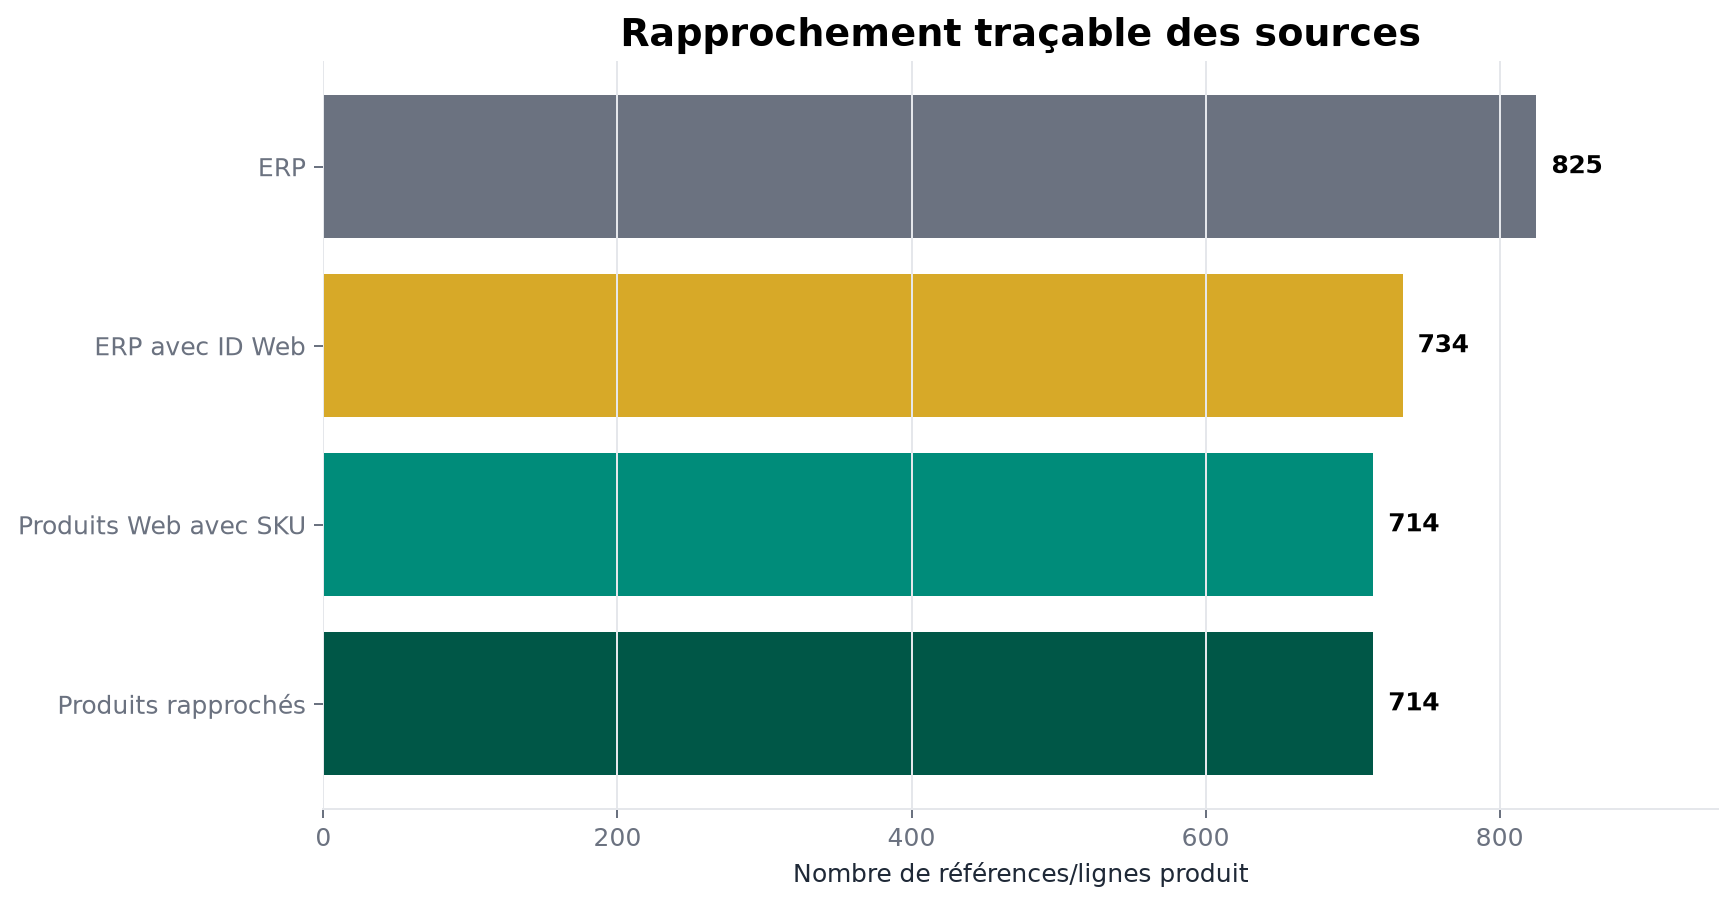

In [3]:
display(result.join_audit)
quality_summary = (
    result.quality_issues.groupby(["category", "severity"], as_index=False)
    .size()
    .rename(columns={"size": "constats"})
)
display(quality_summary)
display(Image(filename=str(ROOT / "reports" / "figures" / "01_rapprochement_sources.png"), width=900))

In [4]:
priority_rules = [
    "erp_price_non_positive",
    "erp_stock_negative",
    "web_sales_invalid",
    "web_product_sku_missing",
    "web_product_attachment_sales_mismatch",
    "erp_marked_online_but_web_missing",
    "web_sales_while_erp_offline",
    "margin_negative",
]
priority_issues = result.quality_issues.loc[
    result.quality_issues["rule_id"].isin(priority_rules),
    ["rule_id", "source", "key", "raw_value", "category", "description", "action"],
]
display(priority_issues)

,rule_id,source,key,raw_value,category,description,action
0,erp_price_non_positive,ERP,4233,-20.0,erreur_certaine,"Un prix de vente nul, négatif ou absent n'est ...",Mettre en quarantaine; ne pas appliquer de val...
1,erp_price_non_positive,ERP,5017,-8.0,erreur_certaine,"Un prix de vente nul, négatif ou absent n'est ...",Mettre en quarantaine; ne pas appliquer de val...
2,erp_price_non_positive,ERP,6594,-9.1,erreur_certaine,"Un prix de vente nul, négatif ou absent n'est ...",Mettre en quarantaine; ne pas appliquer de val...
3,web_product_sku_missing,WEB,NaN,NaN,erreur_certaine,Une ligne produit sans SKU ne peut pas être ra...,Compléter le SKU; exclure du rapprochement san...
4,web_product_sku_missing,WEB,NaN,NaN,erreur_certaine,Une ligne produit sans SKU ne peut pas être ra...,Compléter le SKU; exclure du rapprochement san...
5,web_sales_invalid,WEB,NaN,-56.0,erreur_certaine,Les ventes d'octobre doivent être renseignées ...,Mettre en quarantaine pour le calcul du chiffr...
6,web_sales_invalid,WEB,NaN,-17.0,erreur_certaine,Les ventes d'octobre doivent être renseignées ...,Mettre en quarantaine pour le calcul du chiffr...
7,erp_marked_online_but_web_missing,RAPPROCHEMENT,4594,NaN,anomalie_probable,Référence marquée en vente en ligne dans l'ERP...,Contrôler la publication Web et le mapping.
8,erp_marked_online_but_web_missing,RAPPROCHEMENT,5070,NaN,anomalie_probable,Référence marquée en vente en ligne dans l'ERP...,Contrôler la publication Web et le mapping.
9,erp_marked_online_but_web_missing,RAPPROCHEMENT,5075,NaN,anomalie_probable,Référence marquée en vente en ligne dans l'ERP...,Contrôler la publication Web et le mapping.


### Expérience 1 — choisir les lignes Web par leur sens métier

Critère fixé avant calcul : préserver une ligne par SKU sans dépendre de l'ordre de l'export. Le filtre `post_type == "product"` est comparé aux pièces jointes, au dédoublonnage premier/dernier et à la somme de toutes les lignes.

In [5]:
display(run.web_selection_comparison.style.format({
    "units": "{:,.0f}",
    "revenue_ttc": "{:,.2f} €",
    "revenue_difference_vs_product": "{:+,.2f} €",
    "relative_difference_vs_product": "{:+.2%}",
}))
print("Décision : filtre sémantique 'product'. Un simple keep='first' surévalue ici le CA de 10 068 €, soit 7,01 %.")

,method,matched_skus,units,revenue_ttc,revenue_difference_vs_product,relative_difference_vs_product,decision
0,filtre_semantique_product,714,"5,751","143,680.10 €",+0.00 €,+0.00%,retenu: le type décrit l'entité métier
1,filtre_attachment,714,"6,081","153,748.10 €","+10,068.00 €",+7.01%,rejeté: une pièce jointe n'est pas une vente produit
2,dedoublonnage_garder_premiere_ligne,714,"6,081","153,748.10 €","+10,068.00 €",+7.01%,rejeté: résultat dépendant de l'ordre
3,dedoublonnage_garder_derniere_ligne,714,"5,751","143,680.10 €",+0.00 €,+0.00%,rejeté: résultat dépendant de l'ordre
4,somme_de_toutes_les_lignes,714,"11,832","297,428.20 €","+153,748.10 €",+107.01%,rejeté: double comptage


Décision : filtre sémantique 'product'. Un simple keep='first' surévalue ici le CA de 10 068 €, soit 7,01 %.


## 3. Performance commerciale d'octobre

Le CA est calculé ligne à ligne puis recalculé indépendamment avec `Decimal`. La différence de réconciliation doit rester nulle au centime.

In [6]:
kpis = pd.DataFrame([
    ["CA TTC d'octobre", metrics["sales"]["revenue_october_ttc"], "€"],
    ["Unités vendues", metrics["sales"]["units_sold_october"], "unités"],
    ["Références vendues", metrics["sales"]["references_with_sales"], "références"],
    ["Marge brute d'octobre", metrics["margin"]["gross_margin_october_ht"], "€ HT"],
    ["Taux de marque pondéré", metrics["margin"]["weighted_markup_rate_on_sales"], "%"],
    ["Écart du recalcul indépendant", metrics["sales"]["reconciliation_difference"], "€"],
], columns=["indicateur", "valeur", "unité"])
display(kpis)

,indicateur,valeur,unité
0,CA TTC d'octobre,143680.100000,€
1,Unités vendues,5751.000000,unités
2,Références vendues,689.000000,références
3,Marge brute d'octobre,44660.646667,€ HT
4,Taux de marque pondéré,0.373001,%
5,Écart du recalcul indépendant,0.000000,€


,product_id,id_web,post_title,product_type,price,total_sales,ca_octobre_ttc,marge_octobre_ht,taux_marque,taux_marge_sur_cout,stock_quantity,segment_stock
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0,11.0,2475.0,546.590000,0.265013,0.360569,0,rupture_potentielle
1,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3,6.0,1147.8,260.140000,0.271971,0.373571,98,surstock_gt_12_mois
2,4353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,Champagne,79.5,14.0,1113.0,284.760000,0.307019,0.443041,127,surstock_6_a_12_mois
3,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,Vin,41.2,20.0,824.0,252.466667,0.367670,0.581452,34,couverture_1_a_3_mois
4,6212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,115.0,7.0,805.0,254.893333,0.379965,0.612813,16,couverture_1_a_3_mois
5,5026,13913,Champagne Agrapart &amp; Fils Minéral Extra Br...,Champagne,86.8,9.0,781.2,199.830000,0.306959,0.442915,101,surstock_6_a_12_mois
6,5008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,105.0,7.0,735.0,217.560000,0.355200,0.550868,12,couverture_1_a_3_mois
7,5767,15185,Camille Giroud Clos de Vougeot 2016,Vin,175.0,4.0,700.0,221.653333,0.379977,0.612844,12,couverture_3_a_6_mois
8,6126,14923,Champagne Gosset Célébris Vintage 2007,Champagne,135.0,5.0,675.0,160.850000,0.285956,0.400473,138,surstock_gt_12_mois
9,5025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra...,Champagne,112.0,6.0,672.0,148.400000,0.265000,0.360544,136,surstock_gt_12_mois


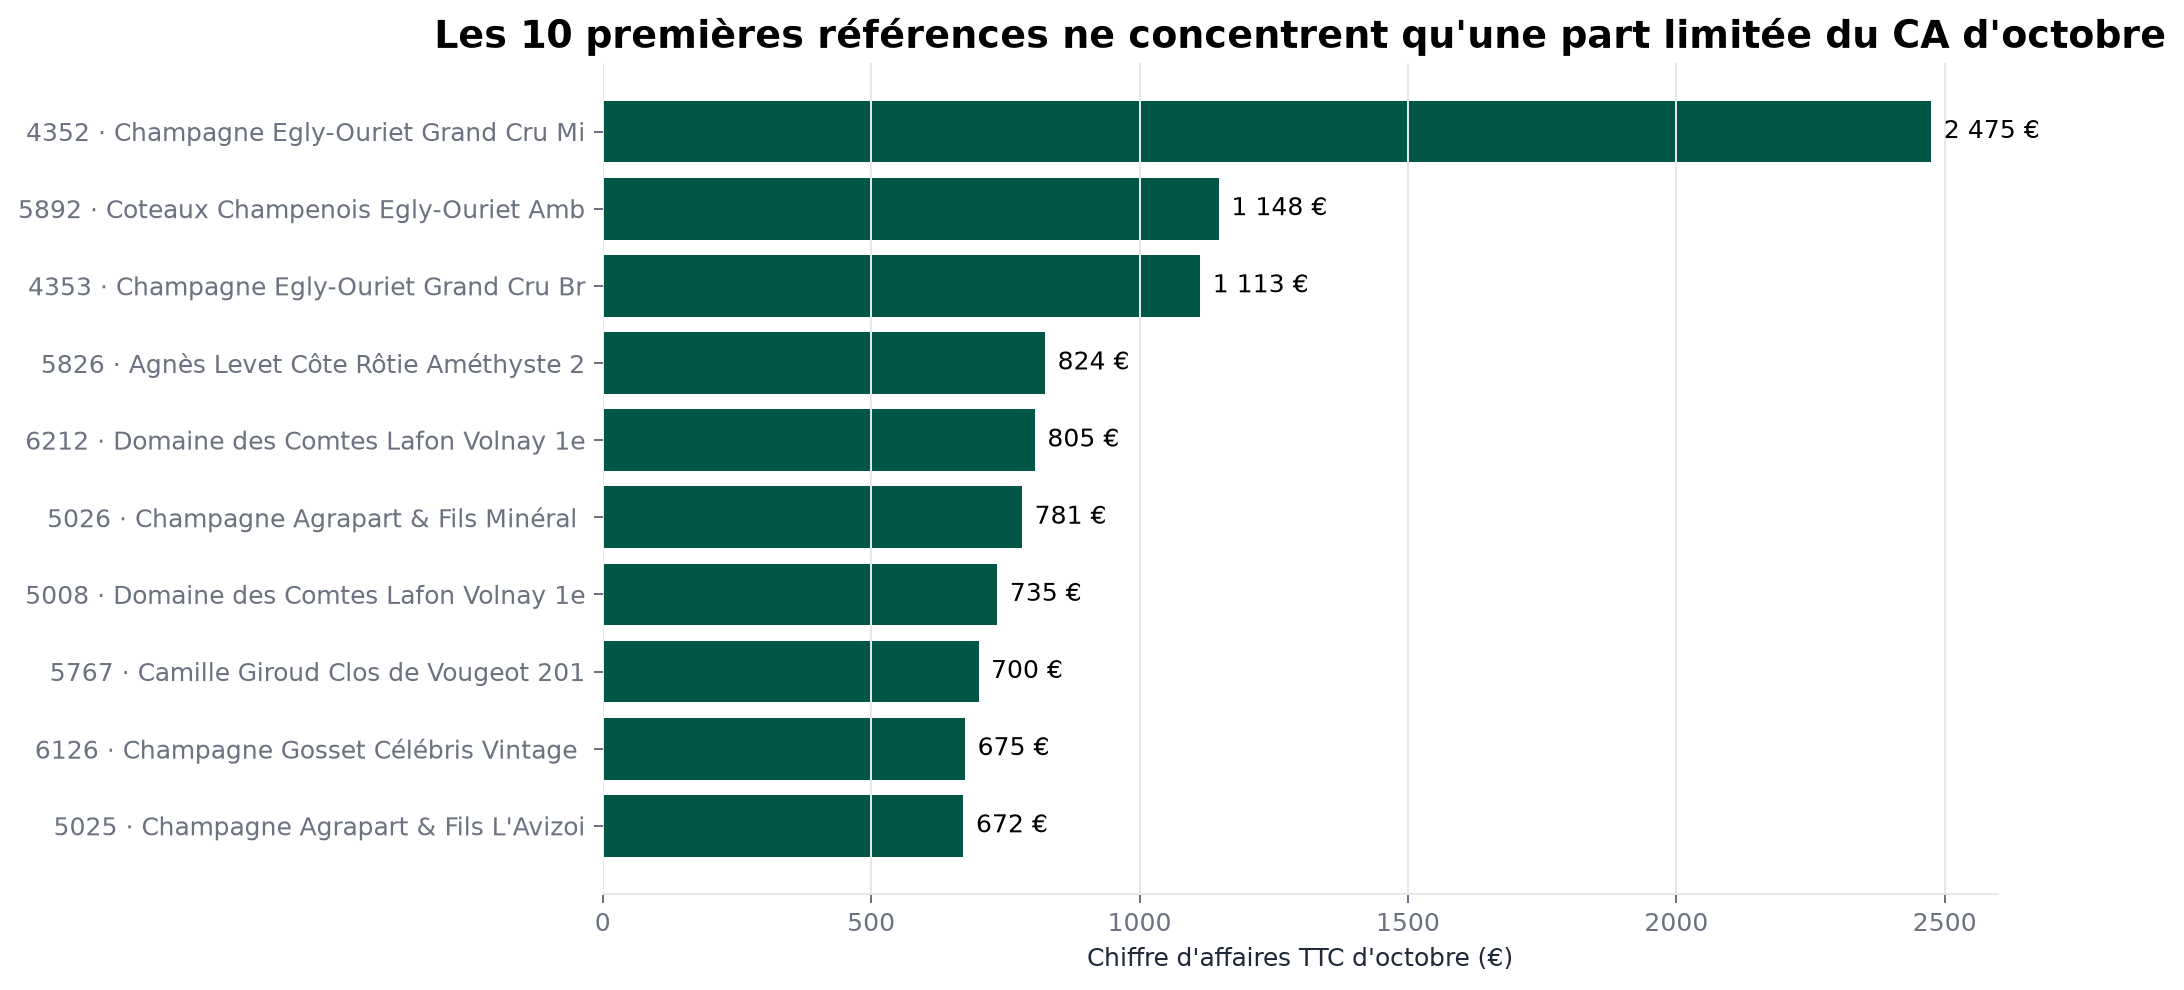

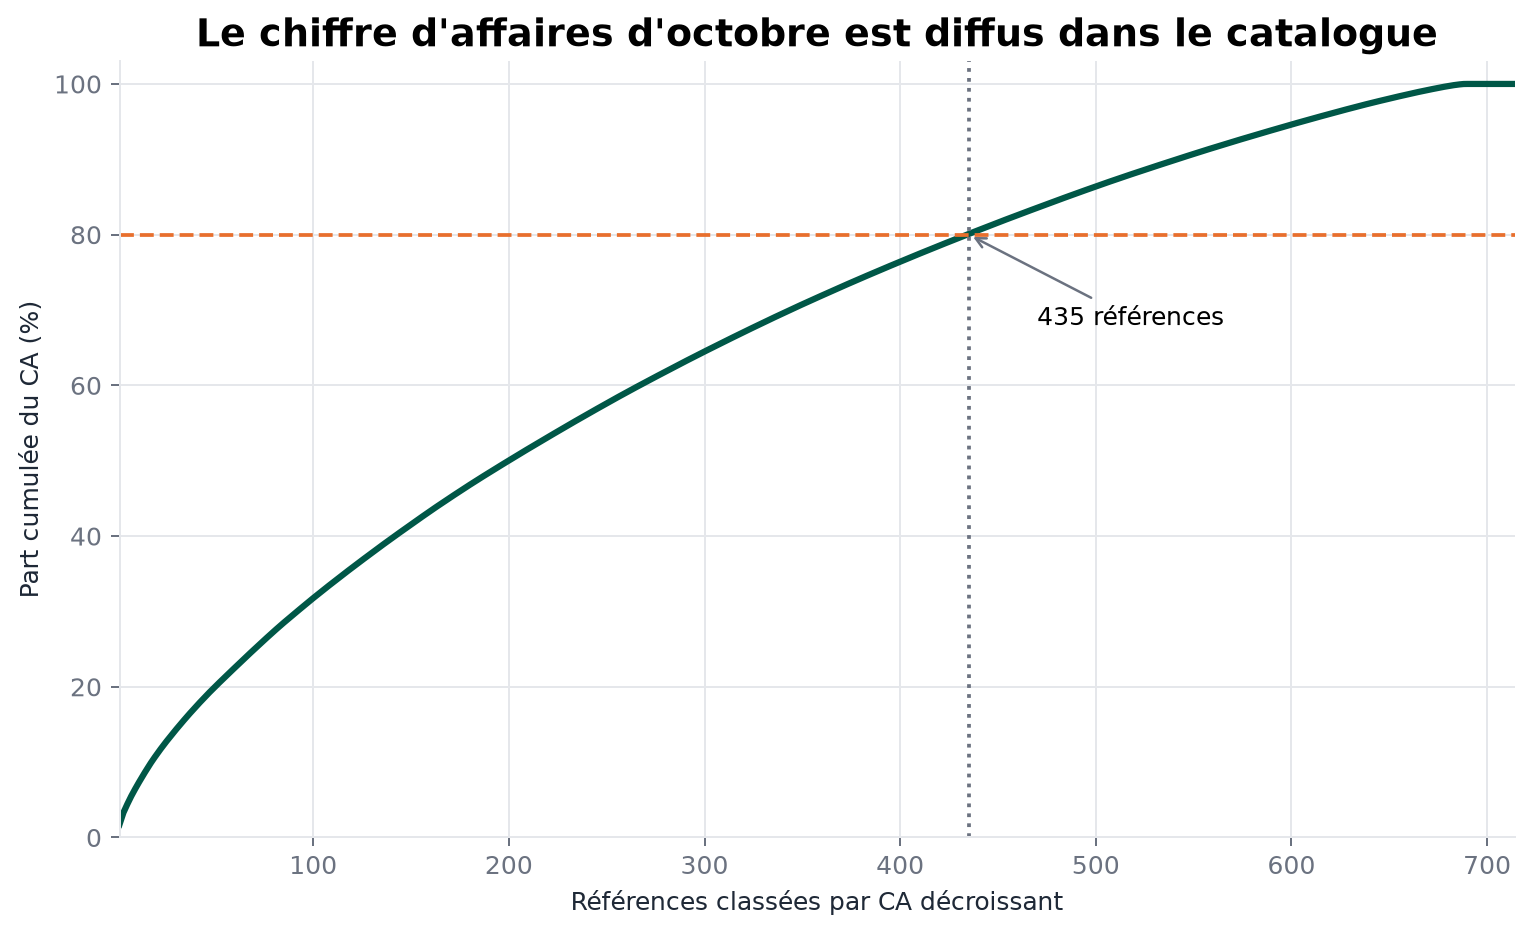

Les 20 premières références représentent 11.0% du CA. Il faut 435 références (60.9% du catalogue rapproché) pour atteindre 80 % : pas de Pareto 20/80.


In [7]:
display(top_products_table(result, 10))
display(Image(filename=str(ROOT / "reports" / "figures" / "02_top10_ca_octobre.png"), width=900))
display(Image(filename=str(ROOT / "reports" / "figures" / "03_pareto_ca_octobre.png"), width=900))
print(
    f"Les 20 premières références représentent {metrics['sales']['top_20_revenue_share']:.1%} du CA. "
    f"Il faut {metrics['sales']['references_for_80pct_revenue']} références "
    f"({metrics['sales']['catalogue_share_for_80pct_revenue']:.1%} du catalogue rapproché) pour atteindre 80 % : pas de Pareto 20/80."
)

## 4. Prix : comparer avant de qualifier

Un prix négatif est une erreur de validité. Un prix élevé est seulement un signal de revue. Quatre méthodes sont testées sur les données réelles et sur 20 anomalies multiplicatives injectées de façon reproductible. Critères : rappel, moins de 5 % d'alertes de base, stabilité de la liste et temps d'exécution.

,method,baseline_alerts,baseline_alert_rate,injected_cases,injected_detected,injected_recall,stability_jaccard,median_runtime_ms
0,iqr_prix_brut,31,4.34%,20,19,95%,0.84,1.976 ms
1,mad_log_prix,0,0.00%,20,0,0%,1.00,1.998 ms
2,mad_prix_brut,33,4.62%,20,20,100%,0.91,2.156 ms
3,zscore_prix_brut,13,1.82%,20,11,55%,0.46,1.301 ms


Décision : MAD sur le prix brut (33 alertes, rappel 100 %, stabilité > 0,90). Les alertes restent dans la catégorie 'inhabituel mais plausible'.


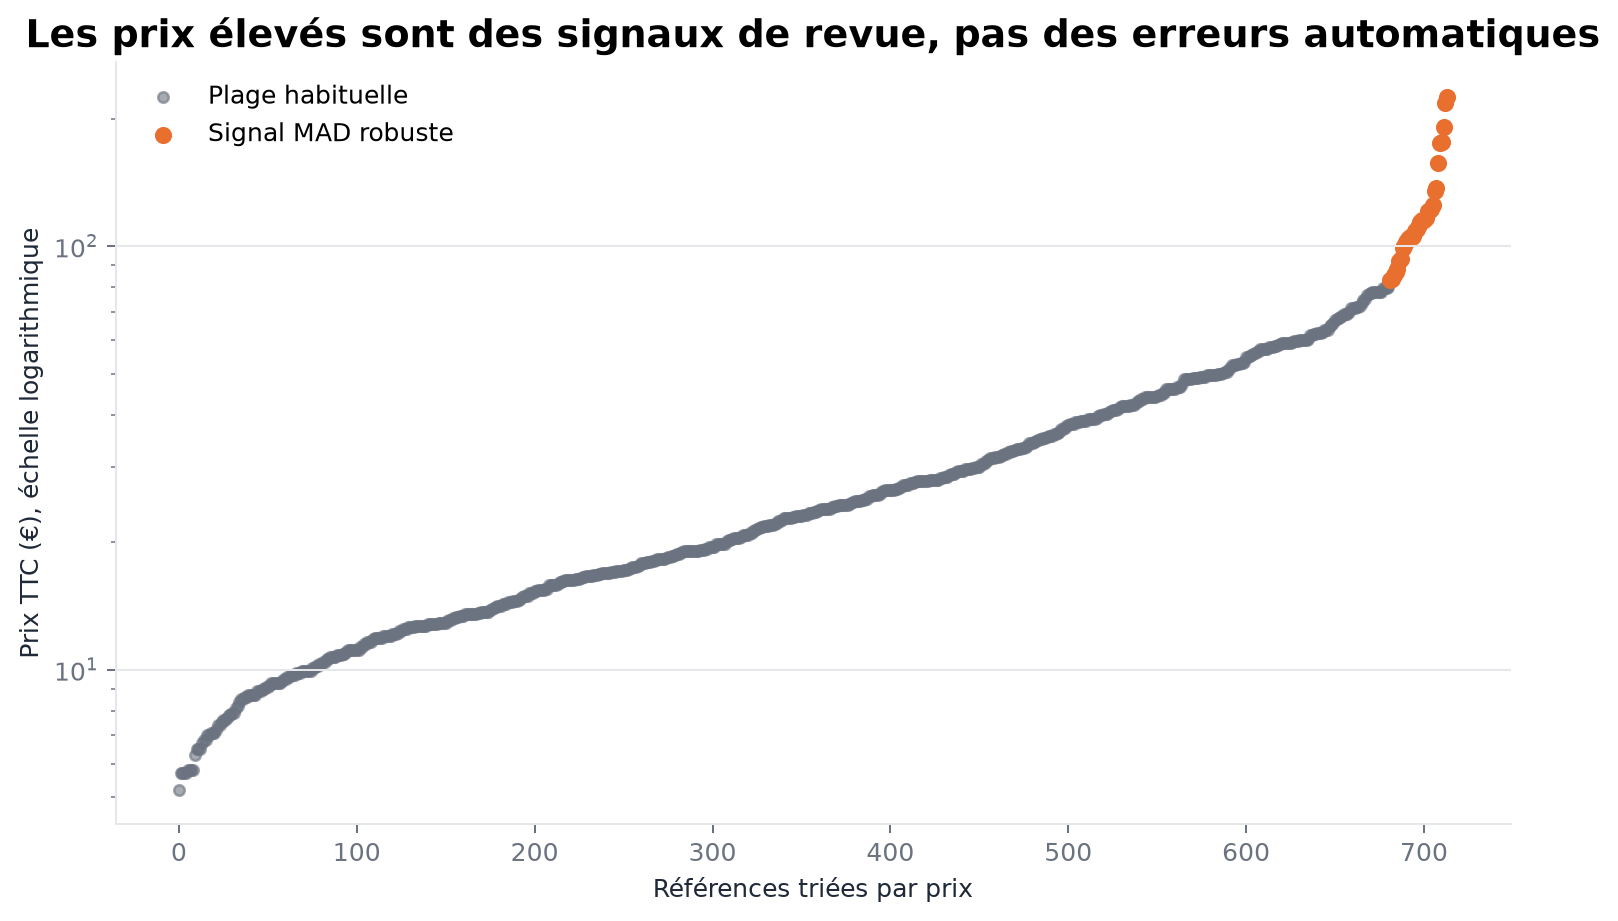

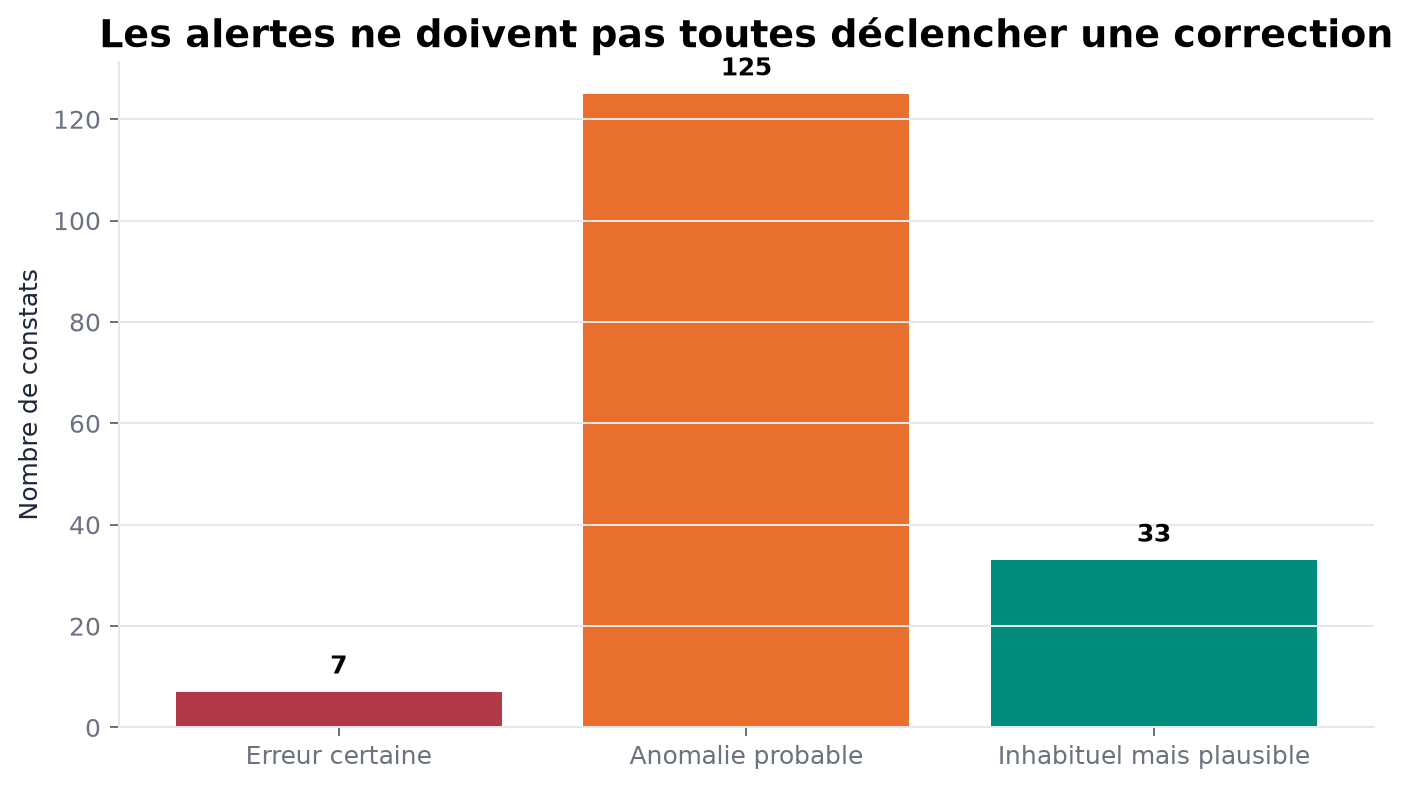

In [8]:
display(run.outlier_comparison.style.format({
    "baseline_alert_rate": "{:.2%}",
    "injected_recall": "{:.0%}",
    "stability_jaccard": "{:.2f}",
    "median_runtime_ms": "{:.3f} ms",
}))
print("Décision : MAD sur le prix brut (33 alertes, rappel 100 %, stabilité > 0,90). Les alertes restent dans la catégorie 'inhabituel mais plausible'.")
display(Image(filename=str(ROOT / "reports" / "figures" / "04_prix_inhabituels.png"), width=900))
display(Image(filename=str(ROOT / "reports" / "figures" / "08_typologie_alertes.png"), width=850))

## 5. Stock au 31 octobre

La valeur comptable indicative est calculée au **coût d'achat HT**. La valeur au prix de vente TTC est conservée séparément et ne doit pas être appelée valorisation comptable. Une référence sans vente en octobre conserve une couverture indéfinie — jamais zéro.

,indicateur,valeur,unité
0,Stock apparié brut signé,16739.00,unités
1,Valeur brute signée au coût,277305.77,€ HT
2,Valeur après exclusion de la quantité négative,277328.07,€ HT
3,Stock sans vente observée,14959.40,€ HT
4,Couverture > 12 mois au rythme d'octobre,95011.92,€ HT
5,Références vendues avec stock final nul,22.00,références


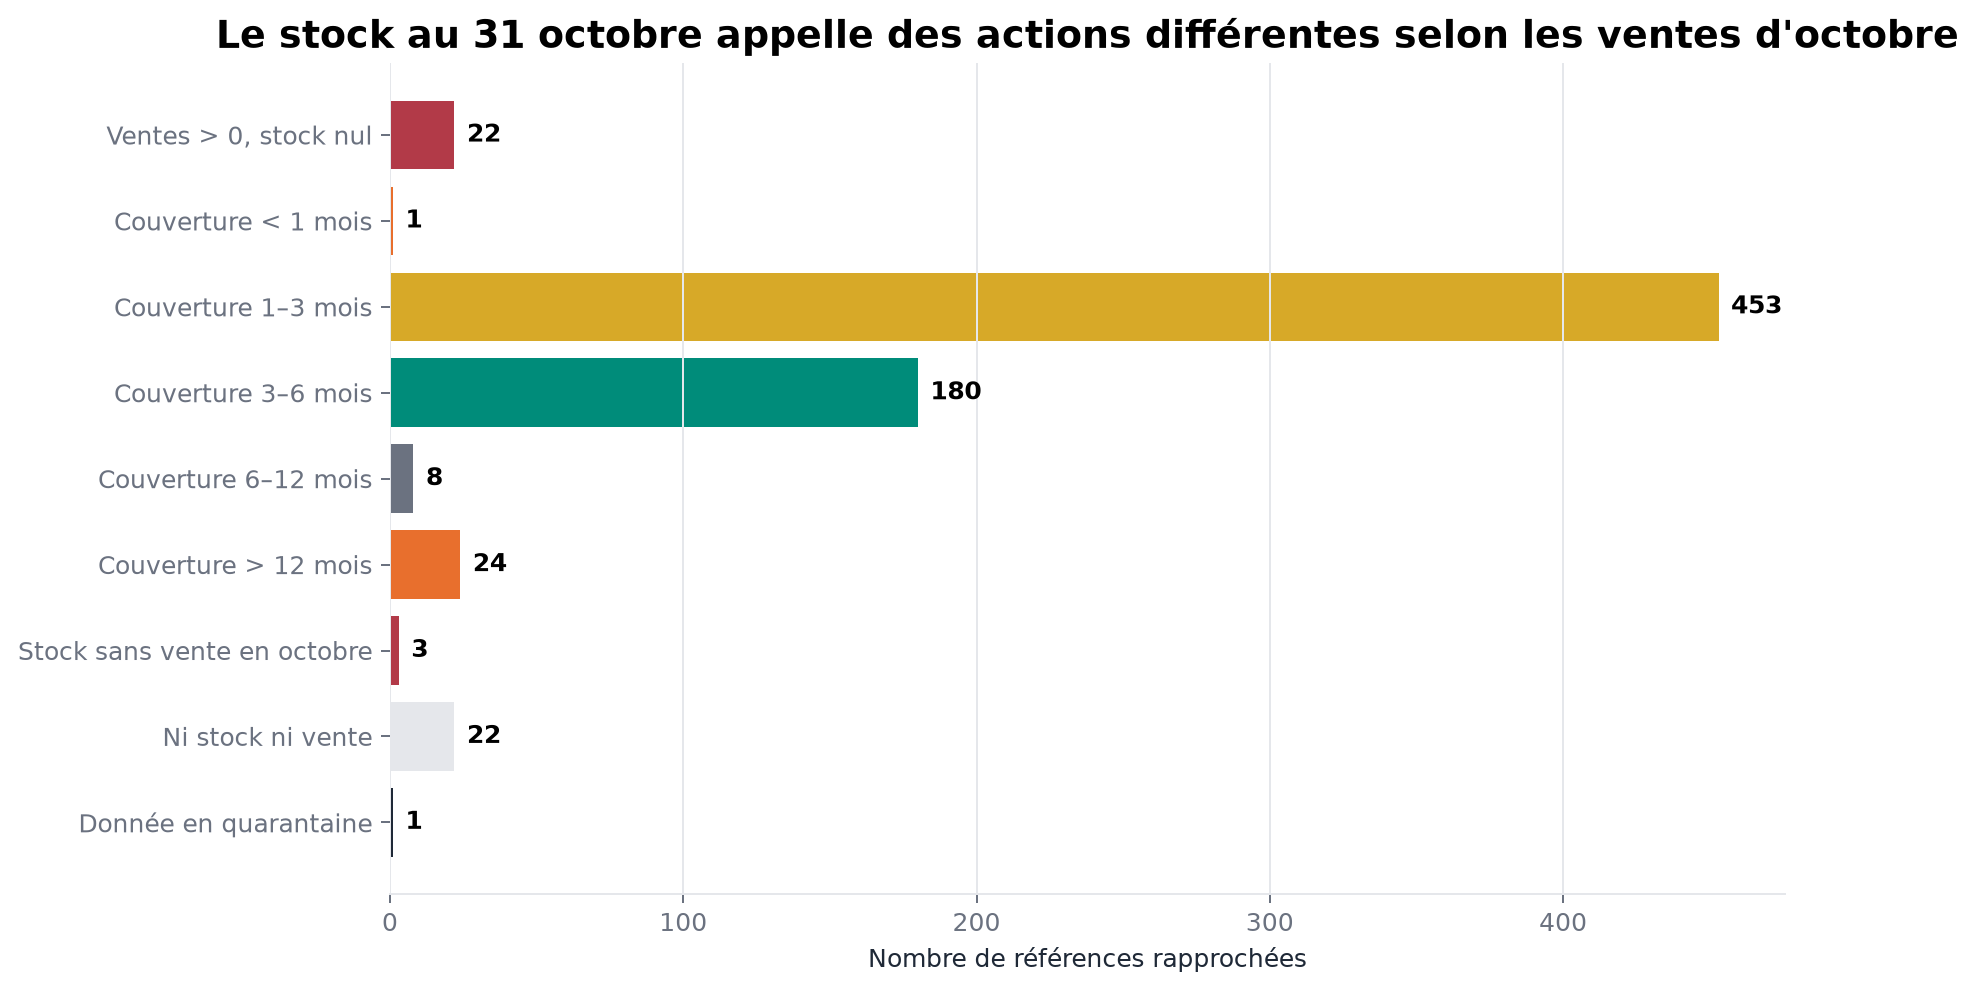

In [9]:
stock = metrics["stock"]
stock_summary = pd.DataFrame([
    ["Stock apparié brut signé", stock["matched_stock_units_raw_signed"], "unités"],
    ["Valeur brute signée au coût", stock["matched_stock_value_cost_ht_raw_signed"], "€ HT"],
    ["Valeur après exclusion de la quantité négative", stock["matched_stock_value_cost_ht"], "€ HT"],
    ["Stock sans vente observée", stock["stock_without_october_sales_value_cost_ht"], "€ HT"],
    ["Couverture > 12 mois au rythme d'octobre", stock["over_12_months_value_cost_ht"], "€ HT"],
    ["Références vendues avec stock final nul", stock["potential_stockout_references"], "références"],
], columns=["indicateur", "valeur", "unité"])
display(stock_summary)
display(Image(filename=str(ROOT / "reports" / "figures" / "05_segments_stock.png"), width=900))

In [10]:
stock_priorities = result.analytic.loc[
    result.analytic["segment_stock"].isin(["stock_sans_vente_octobre", "surstock_gt_12_mois", "rupture_potentielle"]),
    ["product_id", "id_web", "product_type", "total_sales", "stock_quantity", "couverture_au_rythme_octobre_mois", "valeur_stock_cout_ht", "segment_stock"],
].sort_values("valeur_stock_cout_ht", ascending=False)
display(stock_priorities.head(15))

,product_id,id_web,product_type,total_sales,stock_quantity,couverture_au_rythme_octobre_mois,valeur_stock_cout_ht,segment_stock
635,5892,14983,Champagne,6.0,98,16.333333,11373.88,surstock_gt_12_mois
697,6126,14923,Champagne,5.0,138,27.600000,11085.54,surstock_gt_12_mois
475,5025,13914,Champagne,6.0,136,22.666667,9329.60,surstock_gt_12_mois
210,4355,12589,Champagne,0.0,97,NaN,7515.56,stock_sans_vente_octobre
205,4337,4679,Champagne,0.0,145,NaN,7090.50,stock_sans_vente_octobre
207,4350,12588,Champagne,7.0,145,20.714286,6858.50,surstock_gt_12_mois
214,4359,13853,Champagne,7.0,112,16.000000,5816.16,surstock_gt_12_mois
79,4150,1366,Champagne,6.0,123,20.500000,4360.35,surstock_gt_12_mois
206,4348,12586,Champagne,5.0,125,25.000000,4345.00,surstock_gt_12_mois
203,4334,7818,Champagne,7.0,142,20.285714,4261.42,surstock_gt_12_mois


## 6. Marge

Sous hypothèse d'un prix de vente TTC et d'une TVA de 20 %, la formule `(PV HT − coût) / PV HT` est un **taux de marque**. Le taux de marge sur coût est publié séparément. Le coût d'achat aberrant de la référence 4355 est isolé au lieu d'être dilué dans une moyenne de catégorie.

,indicateur,valeur
0,Marge brute d'octobre,44660.646667
1,Taux de marque pondéré,0.373001
2,Taux de marge sur coût,0.594898


,product_id,price,purchase_price,total_sales,stock_quantity,taux_marque,valeur_stock_cout_ht
210,4355,12.65,77.48,0.0,97,-6.349881,7515.56


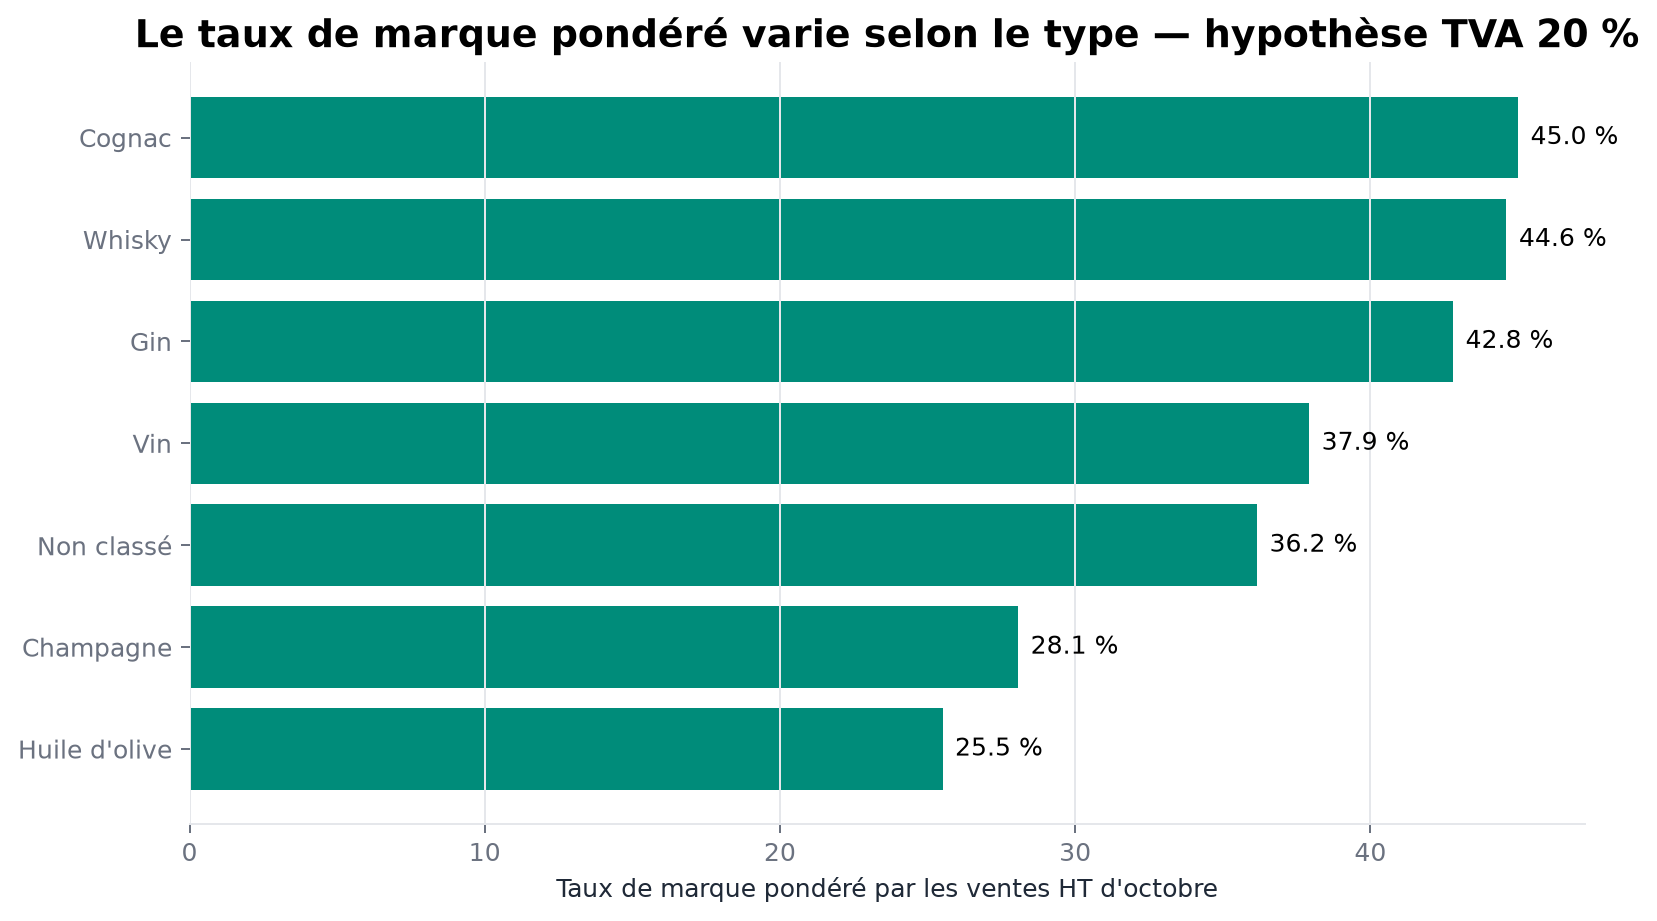

In [11]:
display(pd.DataFrame([
    ["Marge brute d'octobre", metrics["margin"]["gross_margin_october_ht"]],
    ["Taux de marque pondéré", metrics["margin"]["weighted_markup_rate_on_sales"]],
    ["Taux de marge sur coût", metrics["margin"]["margin_rate_on_cost"]],
], columns=["indicateur", "valeur"]))
display(result.analytic.loc[result.analytic["taux_marque"] < 0, [
    "product_id", "price", "purchase_price", "total_sales", "stock_quantity", "taux_marque", "valeur_stock_cout_ht"
]])
display(Image(filename=str(ROOT / "reports" / "figures" / "06_marge_ponderee_type.png"), width=900))

## 7. Relations quantitatives

La corrélation de Spearman limite la sensibilité aux valeurs extrêmes, mais elle ne démontre aucune causalité. Avec un seul mois, elle ne permet ni prévision, ni effet prix, ni recommandation généralisée de baisse de prix.

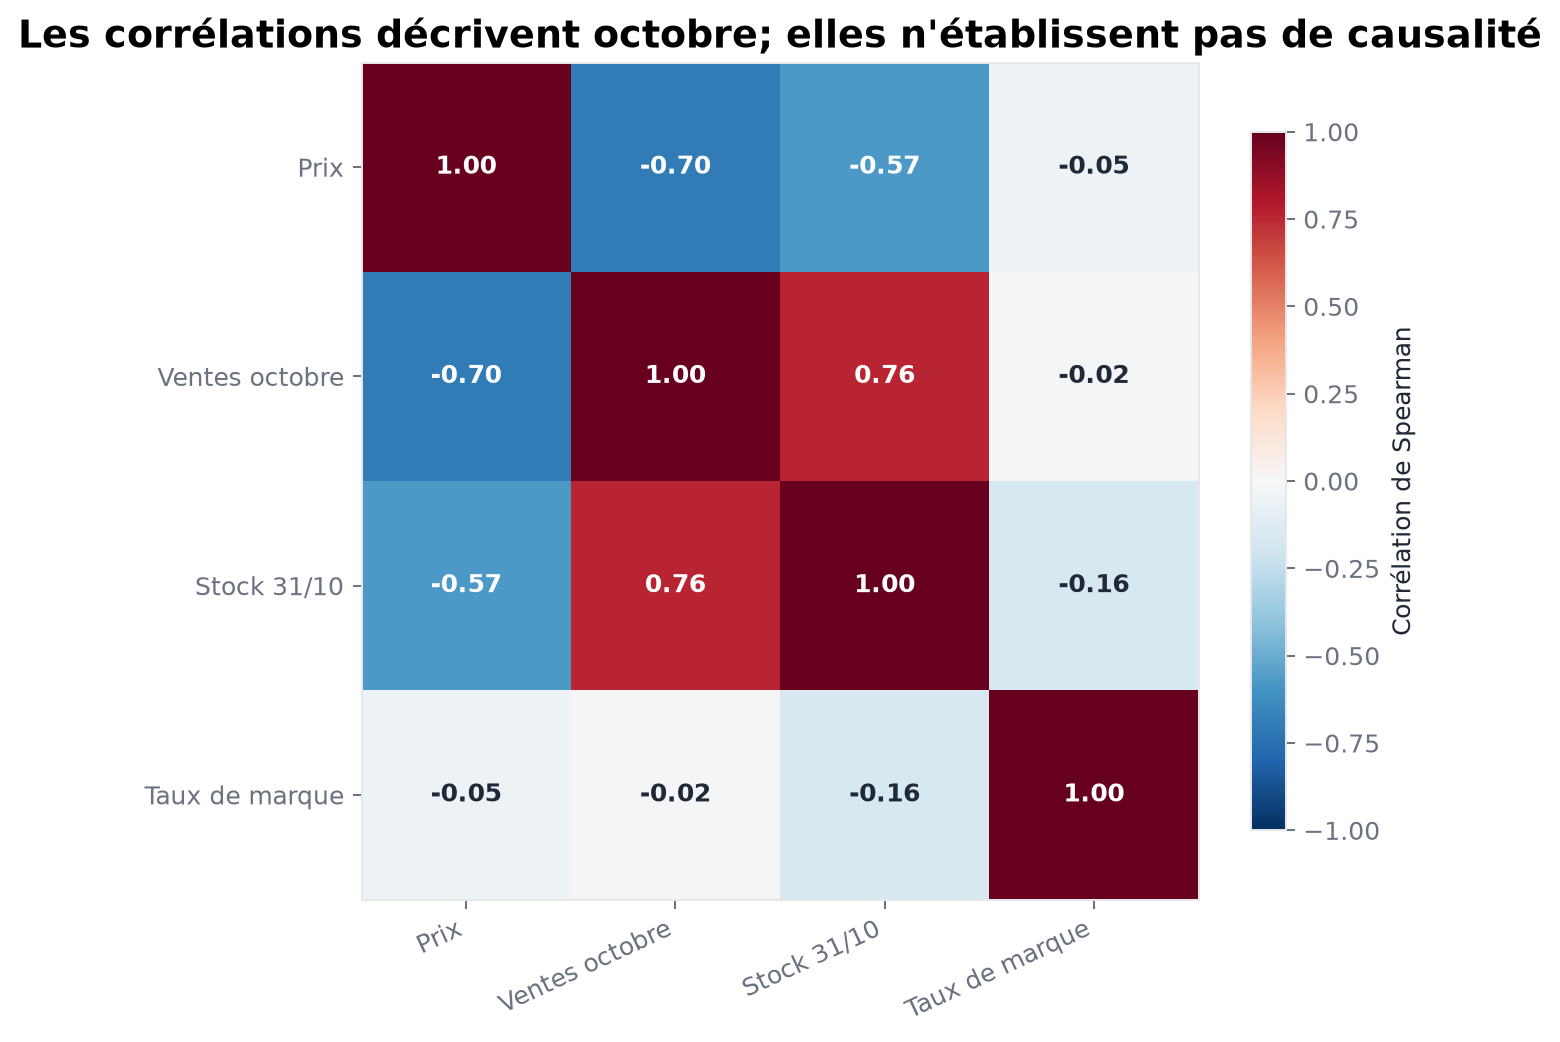

In [12]:
display(Image(filename=str(ROOT / "reports" / "figures" / "07_correlations_spearman.png"), width=800))

## 8. Décisions recommandées

1. **Corriger la qualité avant toute automatisation** : confirmer les 3 prix négatifs, 2 stocks négatifs, 2 ventes négatives sans SKU et la référence 4355.
2. **Réconcilier les statuts ERP/Web** : traiter les 3 références marquées en ligne mais absentes du Web et le produit 4200 vendu malgré `onsale_web=0`.
3. **Piloter le cash immobilisé** : revoir d'abord les 24 références au-delà de 12 mois au rythme d'octobre (95 011,92 € au coût) et les 3 références avec stock mais aucune vente observée (14 959,40 €).
4. **Sécuriser la disponibilité** : examiner les 22 références vendues avec stock final nul.

Les propriétaires, échéances et preuves attendues sont détaillés dans `docs/synthese_codir.md` et `docs/backlog_planning_risques.md`.

## 9. Limites et biais

- Ventes d'un seul mois; aucune tendance ni saisonnalité observable.
- Stock final, pas stock moyen : la « couverture au rythme d'octobre » n'est pas une rotation comptable.
- TVA fixée à 20 % et prix d'achat supposé HT; ces conventions doivent être confirmées.
- Les ventes Web sans SKU sont en quarantaine; le rapprochement par GUID est un candidat, pas une correction automatique.
- Les produits non rapprochés n'ont pas de ventes Web observables dans ce jeu : absence de donnée ne signifie pas zéro vente.
- Les prix signalés par MAD peuvent être des vins premium valides; aucune suppression statistique automatique.

Les détails complets figurent dans `docs/limites_biais.md`.

## 10. Reproduction

Depuis la racine du dépôt :

```powershell
python -m venv .venv
.\.venv\Scripts\python.exe -m pip install -r requirements-dev.txt
.\.venv\Scripts\python.exe -m pytest -q
.\.venv\Scripts\python.exe scripts\run_analysis.py
.\.venv\Scripts\python.exe scripts\execute_notebook.py
```

Le notebook, les CSV, le JSON d'indicateurs et les figures sont régénérés à partir des trois classeurs placés dans `data/raw/`.